In [5]:
# Quiz:02 Receipt Detection
# ============================================================
# STEP 1 — INSTALL LIBRARIES
# ============================================================

get_ipython().system('pip install -q opencv-python matplotlib')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

print("Libraries installed and imported.")

Libraries installed and imported.


In [2]:
# ============================================================
# STEP 2 — INSTALL / FIX PYTORCH
# ============================================================
get_ipython().system('pip uninstall -y torch torchvision torchaudio -q')
get_ipython().system('pip install -q --no-cache-dir torch torchvision torchaudio')

print("PyTorch installation completed.")
print("NOW GO TO: Runtime -> Restart session")
print("After restarting, run CELL 3 onward.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 150.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 124.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# ============================================================
# STEP 3 — CHECK PYTORCH
# ============================================================

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.14.0+cu130
CUDA available: False
Running on CPU


In [2]:
# ============================================================
# STEP 4 — INSTALL TRANSFORMERS
# ============================================================

get_ipython().system('pip install -q transformers')

print("Transformers installed successfully!")

Transformers installed successfully!


In [3]:
# ============================================================
# STEP 5 — LOAD GROUNDING DINO MODEL
# ============================================================

import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model_id = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id)
model = model.to(device)

print("Grounding DINO loaded successfully!")


Device: cpu


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  689MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Grounding DINO loaded successfully!


In [6]:
# ------------------------------------------------------------
# 1. Upload image
# ------------------------------------------------------------

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
if img is None:
    raise ValueError("Image could not be read.")

H, W = img.shape[:2]
print("Image:", image_path)
print("Image size:", W, "x", H)

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pil_image = Image.fromarray(image_rgb)

text_labels = [[
    "a receipt",
    "a paper receipt",
    "a shopping receipt"
]]

Saving input_image.jpeg to input_image.jpeg
Image: input_image.jpeg
Image size: 1085 x 1542


In [7]:
# ------------------------------------------------------------
# 2. IoU helper (measures how much two boxes overlap)
# ------------------------------------------------------------

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    iw = max(0, x2 - x1)
    ih = max(0, y2 - y1)
    intersection = iw * ih

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union else 0

In [8]:
# ------------------------------------------------------------
# 3. Run one detection pass at given thresholds
# ------------------------------------------------------------

def run_detection(threshold, text_threshold):

    inputs = processor(images=pil_image, text=text_labels, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs["input_ids"],
        threshold=threshold,
        text_threshold=text_threshold,
        target_sizes=[(H, W)]
    )[0]

    boxes = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()

    candidates = []
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = map(int, box)
        x1 = max(0, min(x1, W - 1))
        y1 = max(0, min(y1, H - 1))
        x2 = max(0, min(x2, W - 1))
        y2 = max(0, min(y2, H - 1))

        bw, bh = x2 - x1, y2 - y1
        if bw <= 0 or bh <= 0:
            continue

        area = bw * bh
        area_ratio = area / (W * H)
        aspect_ratio = bw / bh

        # Remove too-small or too-large regions
        if area_ratio < 0.015 or area_ratio > 0.30:
            continue
        # Keep only receipt-like shapes (tall/narrow to roughly square)
        if aspect_ratio < 0.20 or aspect_ratio > 1.50:
            continue

        candidates.append({"box": (x1, y1, x2, y2), "score": float(score), "area": area})

    # Sort by confidence (most certain detections first)
    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)

    # Remove duplicate/overlapping boxes, keeping the most confident one
    selected = []
    for c in candidates:
        if not any(calculate_iou(c["box"], s["box"]) > 0.30 for s in selected):
            selected.append(c)

    return selected

In [9]:
# ------------------------------------------------------------
# 4. Try progressively lower thresholds until we find enough receipts
# ------------------------------------------------------------

EXPECTED_RECEIPTS = 5
MAX_RECEIPTS = 10

selected = []
for t in [0.20, 0.17, 0.15, 0.12, 0.10]:
    selected = run_detection(threshold=t, text_threshold=max(t - 0.05, 0.05))
    print(f"Threshold {t}: found {len(selected)} candidate receipt(s)")
    if len(selected) >= EXPECTED_RECEIPTS:
        print(f"Reached target of {EXPECTED_RECEIPTS} at threshold {t}")
        break

selected = selected[:MAX_RECEIPTS]

if len(selected) < EXPECTED_RECEIPTS:
    print()
    print("WARNING: only", len(selected), "receipts detected after all threshold attempts.")
else:
    print()
    print(f"SUCCESS: {len(selected)} receipt(s) detected.")

Threshold 0.2: found 5 candidate receipt(s)
Reached target of 5 at threshold 0.2

SUCCESS: 5 receipt(s) detected.


In [10]:
# ------------------------------------------------------------
# 5. Sort receipts top-to-bottom / left-to-right for numbering
# ------------------------------------------------------------

selected = sorted(selected, key=lambda item: (item["box"][1], item["box"][0]))

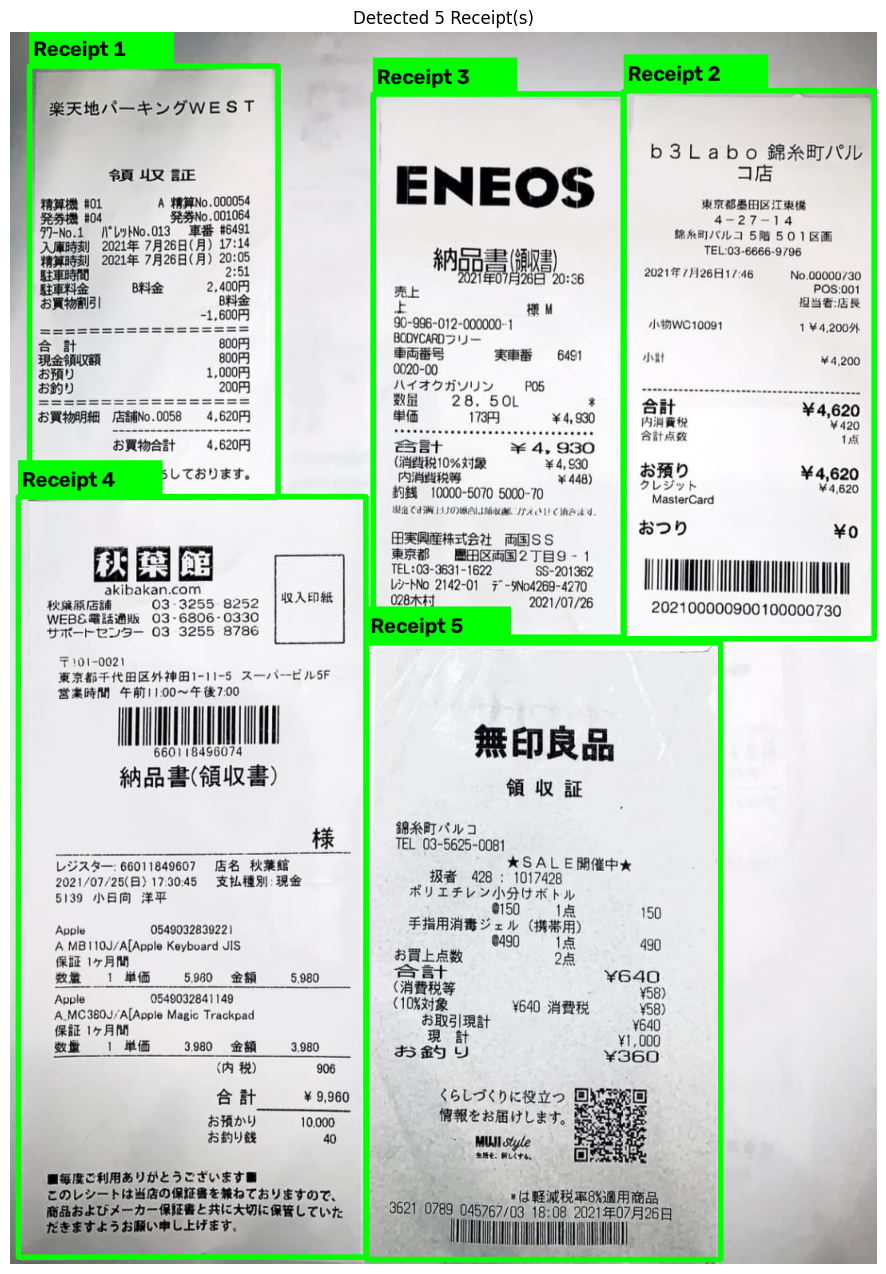

In [11]:
# ------------------------------------------------------------
# 6. Draw boxes on the image for a visual check
# ------------------------------------------------------------

result_img = img.copy()
for i, item in enumerate(selected, 1):
    x1, y1, x2, y2 = item["box"]
    cv2.rectangle(result_img, (x1, y1), (x2, y2), (0, 255, 0), 5)
    cv2.rectangle(result_img, (x1, max(0, y1 - 45)), (x1 + 180, y1), (0, 255, 0), -1)
    cv2.putText(result_img, f"Receipt {i}", (x1 + 5, max(30, y1 - 12)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)

plt.figure(figsize=(12, 16))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(selected)} Receipt(s)")
plt.axis("off")
plt.show()

In [12]:
# ------------------------------------------------------------
# 7. Crop, save each receipt, and log confidence scores
# ------------------------------------------------------------

output_folder = "detected_receipts"
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.makedirs(output_folder)

log_path = os.path.join(output_folder, "detection_log.txt")
with open(log_path, "w") as log_file:
    for i, item in enumerate(selected, 1):
        x1, y1, x2, y2 = item["box"]
        padding = 5
        x1p = max(0, x1 - padding)
        y1p = max(0, y1 - padding)
        x2p = min(W, x2 + padding)
        y2p = min(H, y2 + padding)

        receipt = img[y1p:y2p, x1p:x2p]
        filename = os.path.join(output_folder, f"receipt_{i}.jpg")
        cv2.imwrite(filename, receipt)

        log_line = f"Receipt {i}: confidence={item['score']:.3f}, box=({x1},{y1},{x2},{y2})\n"
        log_file.write(log_line)
        print("Saved:", filename, "| confidence:", round(item["score"], 3))

print("Detection log saved to:", log_path)

Saved: detected_receipts/receipt_1.jpg | confidence: 0.316
Saved: detected_receipts/receipt_2.jpg | confidence: 0.265
Saved: detected_receipts/receipt_3.jpg | confidence: 0.349
Saved: detected_receipts/receipt_4.jpg | confidence: 0.267
Saved: detected_receipts/receipt_5.jpg | confidence: 0.456
Detection log saved to: detected_receipts/detection_log.txt


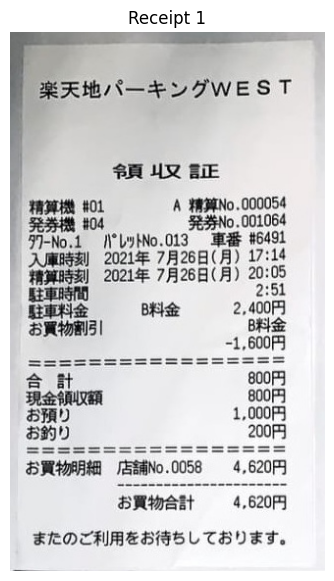

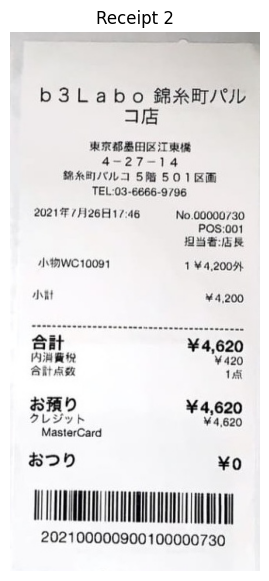

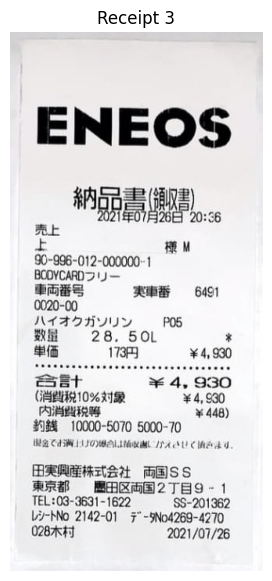

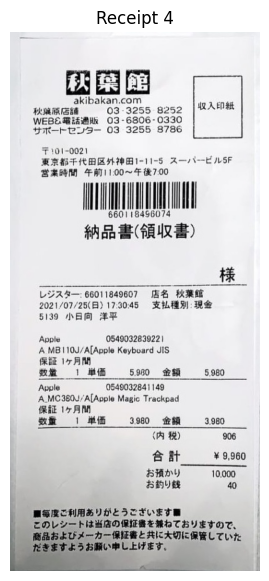

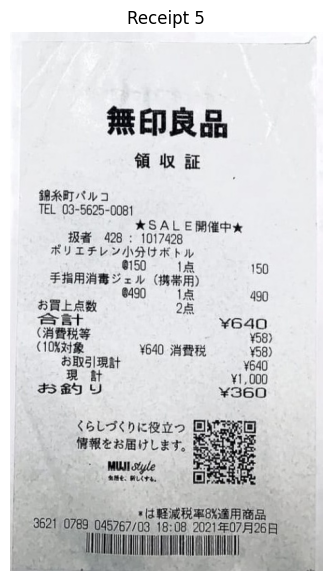

In [13]:
# ------------------------------------------------------------
# 8. Display each cropped receipt individually
# ------------------------------------------------------------

for i in range(1, len(selected) + 1):
    filename = os.path.join(output_folder, f"receipt_{i}.jpg")
    receipt = cv2.imread(filename)
    plt.figure(figsize=(5, 7))
    plt.imshow(cv2.cvtColor(receipt, cv2.COLOR_BGR2RGB))
    plt.title(f"Receipt {i}")
    plt.axis("off")
    plt.show()


In [16]:
import shutil
from google.colab import files
# ------------------------------------------------------------
# 9. Zip everything and download
# ------------------------------------------------------------

zip_path = shutil.make_archive("detected_receipts", "zip", output_folder)

print()
print("======================================")
print("PROCESS COMPLETED")
print("======================================")
print("Detected receipts:", len(selected))
print("ZIP file:", zip_path)

files.download(zip_path)


PROCESS COMPLETED
Detected receipts: 5
ZIP file: /content/detected_receipts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>